# Implementação do solver para o Brasil usando o trabalho final de COS360 como base

## Imports

In [25]:
import pandas as pd
import pulp
import gcsfs
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
from shapely import wkt

## Paths

In [17]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv('GCS_BUCKET_NAME')
STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
INPUT_PATH = f"gs://{BUCKET_NAME}/solver_inputs/candidatos_solver_brasil.csv"

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carregamento de Dados

In [48]:
fs = gcsfs.GCSFileSystem()
with fs.open(INPUT_PATH) as f:
    df_candidatos = pd.read_csv(f, sep=';', decimal=',')

states_gdf = gpd.read_file(STATES_PATH)

print(f"Base carregada com {len(df_candidatos):,} latifúndios.")
print(f"Potencial Total Disponível: {df_candidatos['potencial_mw'].sum()/1000:.2f} GW")

C:\Users\JPMar\AppData\Local\Temp\ipykernel_33936\2647105353.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_candidatos = pd.read_csv(f, sep=';', decimal=',')


Base carregada com 419,133 latifúndios.
Potencial Total Disponível: 80215.13 GW


In [49]:
# Meta Nacional: 8.600 MW
META_MW = 8600 

## Modelagem do problema de otimização

### Modelo com custo do terreno, custo fixo de entrada na rede e limite superior de geração por terreno

In [50]:
print("Definindo restrições físicas e custos de mercado...")

# Definindo um faor de ocupação (área válida para instalação de painéis solares)
FATOR_OCUPACAO = 0.70
df_candidatos['area_efetiva_ha'] = df_candidatos['area_util_ha'] * FATOR_OCUPACAO

# Premissa NREL: 3.6 ha de painéis por MW
df_candidatos['potencial_mw_efetivo'] = df_candidatos['area_efetiva_ha'] / 3.6

# Custo Fundiário (OPEX de Arrendamento trazido a Valor Presente)
ARRENDAMENTO_HA_ANO = 1931
VIDA_UTIL_ANOS = 20
df_candidatos['custo_terra_rs'] = df_candidatos['area_util_ha'] * ARRENDAMENTO_HA_ANO * VIDA_UTIL_ANOS

# OPEX da TUST (Trazido a Valor Presente para 20 anos de vida útil)
TUST_KW_MES = 10.12
TUST_MW_ANO = (TUST_KW_MES * 1000) * 12
VIDA_UTIL_ANOS = 20
df_candidatos['custo_tust_rs'] = df_candidatos['potencial_mw_efetivo'] * TUST_MW_ANO * VIDA_UTIL_ANOS

# Custo Total do Projeto
df_candidatos['custo_total_projeto_rs'] = (
    df_candidatos['custo_conexao_rs'] + 
    df_candidatos['custo_terra_rs'] + 
    df_candidatos['custo_tust_rs']
)

Definindo restrições físicas e custos de mercado...


## Execução do solver sobre o modelo

### Solver para os três cenários do PDE

In [51]:
candidatos_localizacao = df_candidatos.copy()
df_candidatos.drop(columns='geometry', inplace=True)

In [7]:
# Definição das Metas
cenarios = {
    "Pessimista (80%)": META_MW * 0.8,
    "Referência (100%)": META_MW,
    "Otimista (120%)": META_MW * 1.2
}

resultados_cenarios = []
indices = df_candidatos.index

selecionados_cenarios = {}

solver = pulp.PULP_CBC_CMD(
    msg=True,
    gapRel=0.01,
    #, maxSeconds=300
    )

for nome_cenario, meta_mw in cenarios.items():
    print(f"Otimizando o cenário: {nome_cenario} (Meta: {meta_mw:.2f} MW)")
    
    # Iniciar o Problema
    prob = pulp.LpProblem(f"Otimizacao_Solar_BR_{nome_cenario[:3]}", pulp.LpMinimize)
    x = pulp.LpVariable.dicts(f"fazenda_{nome_cenario[:3]}", indices, cat='Binary')
    
    # Função Objetivo: Minimizar Custo Total
    prob += pulp.lpSum([df_candidatos.loc[i, 'custo_total_projeto_rs'] * x[i] for i in indices])
    
    # Restrição: Atingir a Meta (Potencial limitado a 300 MW por usina)
    prob += pulp.lpSum([df_candidatos.loc[i, 'potencial_mw_efetivo'] * x[i] for i in indices]) >= meta_mw
    
    prob.solve(solver)
    
    # Extrair métricas
    selecionados_idx = [i for i in indices if pulp.value(x[i]) == 1.0]
    df_selecionados = df_candidatos.loc[selecionados_idx]
    potencial_alocado = df_selecionados['potencial_mw_efetivo'].sum()
    custo_bilhoes = pulp.value(prob.objective) / 1e9
    selecionados_cenarios[nome_cenario] = df_selecionados

    resultados_cenarios.append({
        "Cenário": nome_cenario,
        "Meta PDE (MW)": meta_mw,
        "Alocado (MW)": potencial_alocado,
        "Fazendas Escolhidas": len(selecionados_idx),
        "Custo Total (R$ Bilhões)": round(custo_bilhoes, 3),
        "Custo Médio (R$ Milhões/MW)": round((custo_bilhoes * 1000) / potencial_alocado, 2)
    })
    print(f"    [Concluído] Status: {pulp.LpStatus[prob.status]}\n")

# Exibição do Balanço Final
print("="*100)
print("BALANÇO FINAL DE OTIMIZAÇÃO (BRASIL - PDE 2034)")
print("="*100)
df_resultados = pd.DataFrame(resultados_cenarios)
print(df_resultados.to_string(index=False))
# print(selecionados_cenarios["Pessimista (80%)"].to_string(index=False))
# print(selecionados_cenarios["Referência (100%)"].to_string(index=False))
# print(selecionados_cenarios["Otimista (120%)"].to_string(index=False))
print("="*100)

Otimizando o cenário: Pessimista (80%) (Meta: 6880.00 MW)
    [Concluído] Status: Optimal

Otimizando o cenário: Referência (100%) (Meta: 8600.00 MW)
    [Concluído] Status: Optimal

Otimizando o cenário: Otimista (120%) (Meta: 10320.00 MW)
    [Concluído] Status: Optimal

BALANÇO FINAL DE OTIMIZAÇÃO (BRASIL - PDE 2034)
          Cenário  Meta PDE (MW)  Alocado (MW)  Fazendas Escolhidas  Custo Total (R$ Bilhões)  Custo Médio (R$ Milhões/MW)
 Pessimista (80%)         6880.0   6880.401079                   37                    18.085                         2.63
Referência (100%)         8600.0   8600.158205                   12                    22.598                         2.63
  Otimista (120%)        10320.0  10320.096568                   23                    27.117                         2.63


In [52]:
# selecionados_cenarios["Pessimista (80%)"].sort_values(by='nome_imovel', ascending=False)

In [53]:
candidatos_localizacao["geometry"] = candidatos_localizacao["geometry"].apply(wkt.loads)

In [58]:
fazendas_gdf = gpd.GeoDataFrame(candidatos_localizacao, geometry="geometry", crs="EPSG:5880")

In [59]:
fazendas_pessimista = fazendas_gdf.loc[selecionados_cenarios["Pessimista (80%)"].index]
fazendas_referencia = fazendas_gdf.loc[selecionados_cenarios["Referência (100%)"].index]
fazendas_otimista = fazendas_gdf.loc[selecionados_cenarios["Otimista (120%)"].index]

fazendas_pessimista = fazendas_pessimista.to_crs(states_gdf.crs)
fazendas_referencia = fazendas_referencia.to_crs(states_gdf.crs)
fazendas_otimista = fazendas_otimista.to_crs(states_gdf.crs)


In [60]:
# 1. Checagem de segurança: veja se não está vazio e que cara têm as coordenadas
print(f"Fazendas no dataframe: {len(fazendas_referencia)}")
print(fazendas_referencia.geometry.head())

Fazendas no dataframe: 12
3      POINT (-55.34356 -11.80181)
4       POINT (-36.53778 -8.99938)
33      POINT (-35.65085 -5.18688)
41       POINT (-56.5421 -20.2142)
298    POINT (-55.31802 -20.73941)
Name: geometry, dtype: geometry


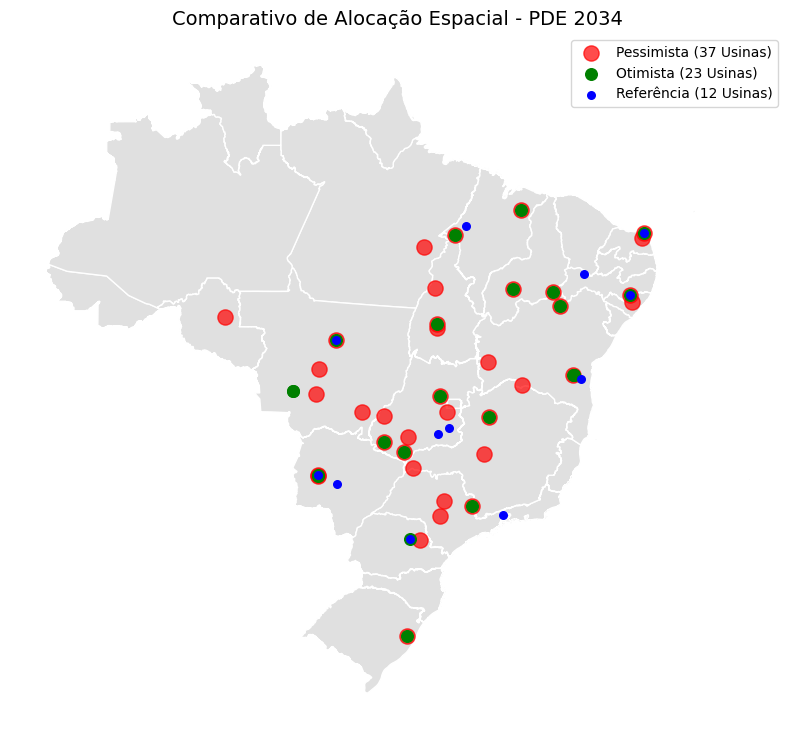

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Fundo do Brasil
states_gdf.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=1)

# Plota do maior conjunto (Pessimista - 37) para o menor (Referência - 12)
fazendas_pessimista.plot(ax=ax, color="red", markersize=120, label="Pessimista (37 Usinas)", alpha=0.7)
fazendas_otimista.plot(ax=ax, color="green", markersize=70, label="Otimista (23 Usinas)")
fazendas_referencia.plot(ax=ax, color="blue", markersize=30, label="Referência (12 Usinas)")

ax.set_title("Comparativo de Alocação Espacial - PDE 2034", fontsize=14)
ax.set_axis_off()
plt.legend()
plt.show()

In [62]:
set_pessimista = set(fazendas_pessimista.index)
set_referencia = set(fazendas_referencia.index)
set_otimista = set(fazendas_otimista.index)

print(f"Fazendas em comum (Pessimista x Otimista): {len(set_pessimista & set_otimista)}")
print(f"Fazendas em comum (Referência x Otimista): {len(set_referencia & set_otimista)}")
print(f"Fazendas em comum (Referência x Pessimista): {len(set_referencia & set_pessimista)}")
print(f"Fazendas que aparecem nos TRÊS cenários: {len(set_pessimista & set_referencia & set_otimista)}")

Fazendas em comum (Pessimista x Otimista): 18
Fazendas em comum (Referência x Otimista): 5
Fazendas em comum (Referência x Pessimista): 4
Fazendas que aparecem nos TRÊS cenários: 4
